## Part 1: Data Visualization

We first found the Titanic dataset from Kaggle, linked here: https://www.kaggle.com/competitions/titanic/overview. Seaborn has the titanic dataset built-in, so we decided to use that for convenience.

The dataset contains 891 rows of training data and 418 rows of test data. We applied binary classification to predict passenger survival (1 for survived, 0 for deceased) based on a variety of demographic and travel-related features.

We used 12 feature dimensions for each passenger which includes:
- `Survival`: 0 = deceased, 1 = survived
- `PassengerId` and `Ticket`: unique identifiers for each passenger
- `Pclass`: socioeconomic status (1st, 2nd, or 3rd class)
- `Name`, `Sex`, and `Age`: basic demographic information
- `SibSp` and `Parch`: family size metrics (siblings/spouses and parents/children)
- `Fare`, `Cabin`, and `Embarked`: trip details including the price, room, and port of departure


There are some missing values (N/A) for `Age`, `Cabin`, and `Embarked`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabi

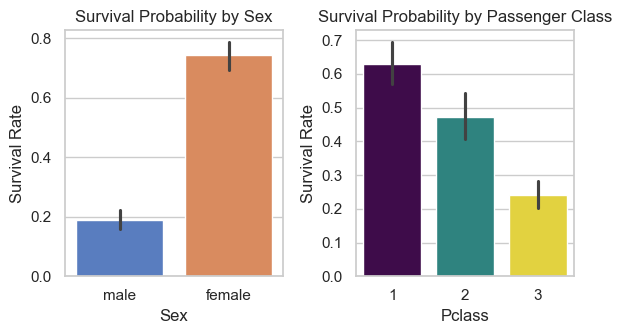

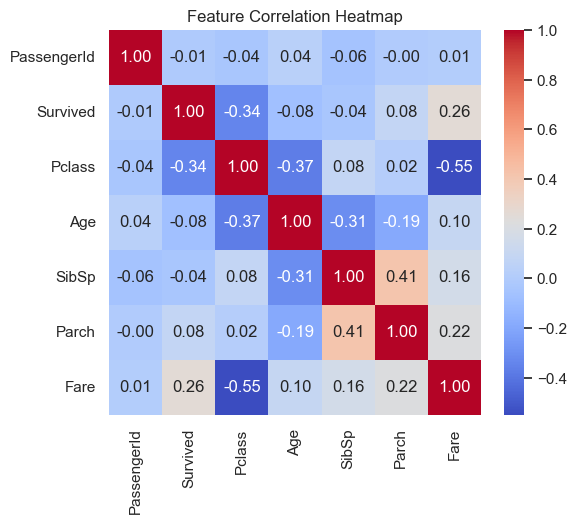

In [13]:
train_df = pd.read_csv('train.csv')

# Quick Data Inspection
print("--- Dataset Info ---")
print(train_df.info())
print("\n--- Missing Values ---")
print(train_df.isnull().sum())

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(6, 3.5))

# Survival by Sex
sns.barplot(x='Sex', y='Survived', data=train_df, ax=ax[0], palette='muted', hue='Sex', legend=False)
ax[0].set_title('Survival Probability by Sex')
ax[0].set_ylabel('Survival Rate')

# Survival by Class
sns.barplot(x='Pclass', y='Survived', data=train_df, ax=ax[1], palette='viridis', hue='Pclass', legend=False)
ax[1].set_title('Survival Probability by Passenger Class')
ax[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# Correlation Heatmap (for numerical features only)
plt.figure(figsize=(6, 5))
numeric_df = train_df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Part 2: Data Cleaning

Since there are some missing values, we decided to use the following methods to clean up the data: